# SR Tutorial

2026 IAIFI Summer School

Tutorial lead: Jose M Munoz Arias

Professor: Miles Cranmer

# Solving Schrödinger's Equation by Search


In [1]:
# Uncomment on Colab.
# import subprocess, sys
# subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pysr", "sympy>=1.14"], check=True)

In [2]:
import os
os.environ.setdefault("PYTHON_JULIACALL_THREADS", "auto")
os.environ.setdefault("PYTHON_JULIACALL_AUTOLOAD_IPYTHON_EXTENSION", "no")

import time

import numpy as np
import pandas as pd

t0 = time.time()
import pysr
from pysr import PySRRegressor, TemplateExpressionSpec
print(f"pysr {pysr.__version__} imported in {time.time() - t0:.0f}s")

import session3_data as s3
from session3_data import (collocation, harmonic, harmonic_exact, harmonic_energy,
                           classify_front_1d, physical_rows, wavefunction, COLS_1D,
                           radial_grid, coulomb, oscillator, classify_front,
                           best_bound, radial_function, exact_radial, exact_energy,
                           oscillator_energy, energy, parameter, COLS)

REPRO = dict(deterministic=True, parallelism="serial", verbosity=0, progress=False)

pysr 1.5.9 imported in 13s


## 1. What the equation says, if you have not met it

If quantum mechanics is already familiar, skip to section 2. If it is not, this is all we need
and it is less than it looks.

A quantum particle is described by a function $\psi(x)$, and everything measurable about the
particle is read off from that function. The one reading we will use is that $|\psi(x)|^2$ is the
probability density for finding the particle at $x$. The theory does not hand you $\psi$. What it
hands you is an operator built out of the physics of the situation, the Hamiltonian,

$$\hat H \psi = -\tfrac12 \psi''(x) + V(x)\,\psi(x),$$

in units where $\hbar = m = 1$, which we will use throughout so that no constants clutter
anything. The first term is the kinetic energy, and the reason it involves a second derivative is
that curvature of $\psi$ is what momentum looks like in this language, so a state that wiggles
fast is a state that is moving fast. The second term is the potential, the shape of the trap or
the pull of a nucleus, and it is the one thing we get to choose.

Now the part that makes this a familiar object. $\hat H$ takes a function and returns a function,
and it does so linearly, so it behaves exactly like a matrix acting on a vector, with the vector
having one component for every point in space. The states the system is allowed to sit in are the
eigenvectors of that matrix,

$$\hat H \psi = E\,\psi,$$

and that single line is the whole content of the time-independent Schrödinger equation. The
eigenvalue $E$ is the energy of the state. Written out it is

$$-\tfrac12 \psi''(x) + V(x)\,\psi(x) = E\,\psi(x),$$

an eigenvalue problem in which the operator happens to contain a derivative.

Two things separate it from an eigenvalue problem in finite dimensions, and both matter to us.

The first is that not every solution counts. A differential equation like this has solutions for
every value of $E$ you care to name, a continuum of them, and what cuts that continuum down to a
discrete list is the demand that $\psi$ be normalisable, meaning it has to decay rather than blow
up far away. That demand is a boundary condition and not an extra postulate, and the discreteness
of energy levels, the thing the word quantum is named after, is entirely a consequence of it.
Section 4 is where this stops being a remark and starts being our problem.

The second is that we want the eigenvector as a formula rather than as a long array of numbers.
Solving this on a grid is a standard numerical exercise and it gives you a column of values.
Getting $e^{-x^2/2}$ back instead is a different kind of answer, and it is the kind this
morning's tools produce.

## 2. What we are going to do about it

The plan is the physics-informed one. Move everything to one side so the equation reads
"something $= 0$", evaluate that something at a grid of points, and minimise it. Anyone who has
built a physics-informed neural network has done exactly this, with $\psi$ carried by a network
and the derivatives taken by autodiff. Here $\psi$ is carried by a symbolic expression and the
derivatives are exact, and what comes out at the end is something you can read and hand to a
colleague rather than a set of weights.

The potential we will use first is the one every physicist knows cold, so that we can check every
answer against something we already believe. The harmonic oscillator, $V = x^2/2$, has levels at
$E_n = n + \tfrac12$ and eigenfunctions that are a Hermite polynomial times a Gaussian. Those are
the numbers we are trying to reproduce without looking them up.

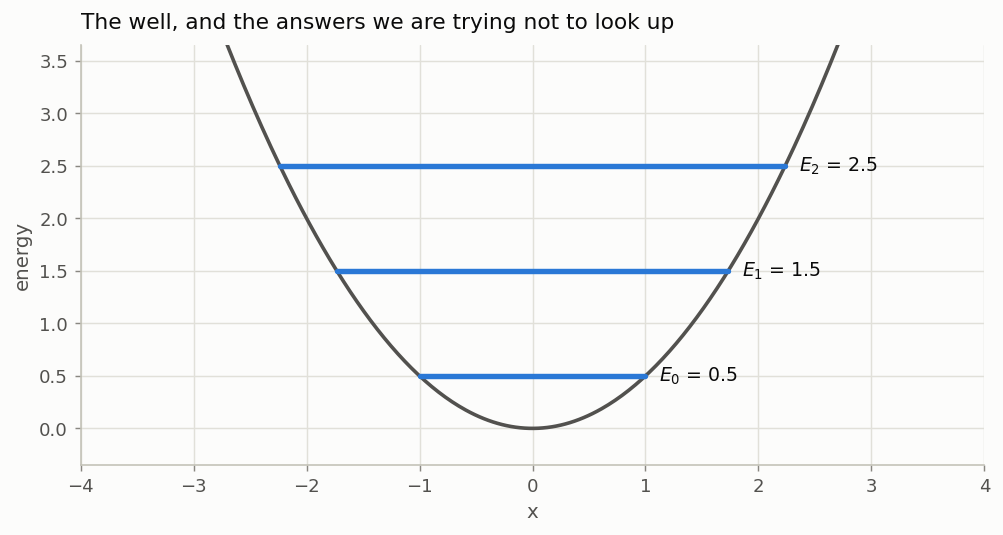

In [3]:
s3.plot_potential()

## 3. The obvious residual, and why it fails

Take a simpler equation first, $f'(x) = f(x)$, whose solution is $e^x$. The natural move is to
build the residual $f'(x) - f(x)$ and ask for it to be zero everywhere.

`D(f, 1)` is the derivative of component `f` with respect to its first argument, and inside the
combine string it is an ordinary Julia value, so it can be composed and differentiated again.
Fitting against a column of zeros with `elementwise_loss="(p, t) -> p^2"` makes the template's own
output the thing being minimised.

In [4]:
x_demo = np.linspace(0.0, 1.0, 60).reshape(-1, 1)

naive = TemplateExpressionSpec(
    expressions=["f"], variable_names=["x"],
    combine="df = D(f, 1); df(x) - f(x)")

t = time.time()
collapse = PySRRegressor(
    expression_spec=naive, binary_operators=["+", "-", "*"], unary_operators=["exp"],
    elementwise_loss="(p, t) -> p^2", niterations=10, maxsize=8,
    random_state=0, **REPRO)
collapse.fit(x_demo, np.zeros(len(x_demo)), variable_names=["x"])
print(f"{time.time() - t:.0f}s")
collapse.equations_[["complexity", "loss", "equation"]]

28s


,complexity,loss,equation
0,1,0.0,f = 0.0


A perfect score, achieved by $f = 0$.

This is worth sitting with for a second, because nothing has gone wrong. Zero really does satisfy
$f' = f$, and it is the shortest expression there is, so a search rewarded for driving a residual
down while keeping expressions small will find it every time. The residual we wrote was a faithful
statement of the equation and a hopeless statement of the problem, since what we wanted was a
*nonzero* solution and we never said so.

Every linear homogeneous differential equation has this property, Schrödinger's included, so we
need a formulation in which the trivial answer is not available.

## 4. Dividing the problem by itself

The trick is to divide through by $\psi$. Define the local energy

$$E_\text{loc}(x) = \frac{-\tfrac12\psi''(x) + V(x)\,\psi(x)}{\psi(x)},$$

which is constant, and equal to $E$, exactly when $\psi$ solves the equation at that $E$, and
which varies with $x$ for anything else. So we ask for $E_\text{loc}(x) - E$ to vanish, with $E$
a fitted parameter.

That does two useful things at once. It kills the trivial solution, since dividing by zero gives a
non-finite residual and PySR discards those candidates outright. And it makes the whole thing
invariant under $\psi \to c\psi$, which is exactly right, because normalisation is not something
the equation determines. Anyone who has done variational Monte Carlo will recognise the local
energy as the quantity that method is built on, and it is the same object here for the same
reason.

The grid carries three ordinary columns: the position, the potential there, and a third column
`w` we will not use until section 6.

In [5]:
X, y = collocation(harmonic, lo=-4.0, hi=4.0, n=120)

LOCAL = ("d1 = D(f, 1); d2 = D(d1, 1); fx = f(x); "
         "(-0.5f0*d2(x) + (V - E[1])*fx) / fx")

SEARCH_1D = dict(binary_operators=["+", "-", "*"], unary_operators=["exp"],
                 elementwise_loss="(p, t) -> p^2", niterations=20, maxsize=14,
                 **REPRO)

def solve_1d(combine, parameters, seed=0, **kw):
    spec = TemplateExpressionSpec(expressions=["f"], variable_names=COLS_1D,
                                  parameters=parameters, combine=combine)
    t = time.time()
    m = PySRRegressor(expression_spec=spec, random_state=seed, **{**SEARCH_1D, **kw})
    m.fit(X, y, variable_names=COLS_1D)
    print(f"{time.time() - t:.0f}s")
    return m

Run it from three different starting points, and read the table carefully. `solved` says the
residual reached zero, so the differential equation holds at every point we sampled. `decay`
measures $|\psi|$ far outside the fitting window against its largest value inside, and `bound`
asks for both.

In [6]:
survey, solutions = [], {}
for seed in range(3):
    m = solve_1d(LOCAL, {"E": 1}, seed=seed)
    f = classify_front_1d(m)
    hit = f[f.solved]
    if len(hit):
        r = hit.iloc[0]
        solutions[seed] = r
        survey.append({"seed": seed, "E": round(r.E, 4), "decay": f"{r.decay:.1e}",
                       "bound": bool(r.bound), "psi": r.equation.split(";")[0]})
    else:
        survey.append({"seed": seed, "E": np.nan, "decay": "-", "bound": False,
                       "psi": "nothing exact found"})
pd.DataFrame(survey)

33s


22s


18s


,seed,E,decay,bound,psi
0,0,0.5,1.3e-14,True,f = exp(#1 * (#1 * -0.499999))
1,1,0.5,1.3e-14,True,f = exp((#1 * -0.4999987) * #1)
2,2,-0.5,1.0e+00,False,f = exp((#1 * #1) * 0.49999845)


## 5. Solving the equation is not the same as finding a state

Some of those came back with $E = +\tfrac12$, which is the answer, and at least one came back with

$$\psi = e^{+x^2/2}, \qquad E = -\tfrac12,$$

which genuinely satisfies $-\tfrac12\psi'' + \tfrac12 x^2\psi = -\tfrac12\psi$ at every point we
sampled. Substitute it and check. It is a real solution of the differential equation and it is not
a state of the harmonic oscillator, because it grows in both directions and cannot be normalised.
There is no energy $-\tfrac12$ in this well and no measurement would ever return one.

Nothing we wrote down excluded it, which is section 1's boundary condition coming back to collect.
We asked for the equation and we did not ask for normalisability, so we got the larger set of
answers that only the equation defines.

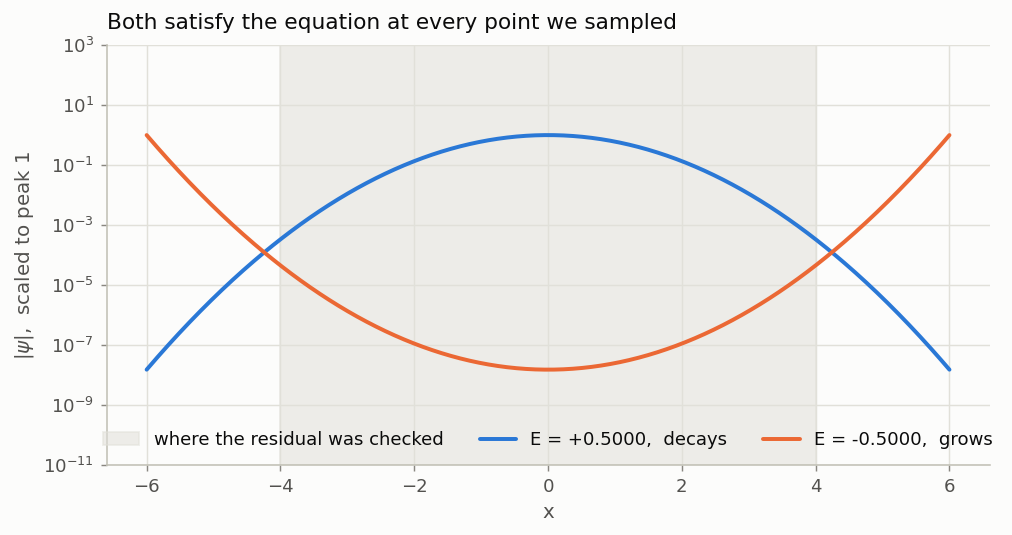

In [7]:
# The same rows the table above reported, so the labels here cannot drift from it.
ok = [s for s, r in solutions.items() if r.bound]
astray = [s for s, r in solutions.items() if not r.bound]

good = solutions[ok[0]]
entries = [(f"E = {good.E:+.4f},  decays", wavefunction(good.equation))]
if astray:
    bad = solutions[astray[0]]
    entries.append((f"E = {bad.E:+.4f},  grows", wavefunction(bad.equation)))
else:
    # Every seed behaved this time; draw the runaway analytically so the point stands.
    entries.append(("E = -0.5000,  grows", lambda g: np.exp(np.asarray(g) ** 2 / 2)))
s3.plot_runaway(entries)

Inside the shaded box the two are equally valid and the search had no way to tell them apart.
Outside it, one of them is a probability distribution and the other is not.

This is the same lesson as this morning's drag problem, where the front fanned out at the origin
because nothing in the data said what happened there. It is worth noticing that it has come back
in a setting with no data at all, which means it was never really about data. It was about the
difference between what we wrote down and what we meant.

## 6. Telling it to decay

The fix is also the one from this morning. When you know something the equation does not say, add
it as a term weighted heavily enough that no candidate can afford to ignore it. Here that means
penalising $\psi$ for being large out in the tails, using the `w` column, which is almost zero
across the middle of the box and climbs steeply at both edges.

The whole change is `+ w*fx*fx` on the end of the residual, and we rerun the seed that went
astray.

In [8]:
ANCHORED = LOCAL + " + w*fx*fx"

fixed = solve_1d(ANCHORED, {"E": 1}, seed=astray[0] if astray else 2)
front0 = classify_front_1d(fixed)
front0[["complexity", "loss", "E", "decay", "solved", "bound"]]

24s


,complexity,loss,E,decay,solved,bound
0,1,5.872743e+00,2.705972,1.000000e+00,False,False
1,3,5.868241e+00,2.762332,1.000000e+00,False,False
2,4,5.820524e+00,2.172292,1.000000e+00,False,False
3,6,1.284710e-05,0.513359,1.316662e-14,False,False
4,8,8.306236e-10,0.500104,1.266871e-14,True,True


f = exp(#1 * (#1 * -0.4999944)) * -0.08391304; E = [0.50010353]
E = 0.500104    exact 0.5      decay 1.27e-14


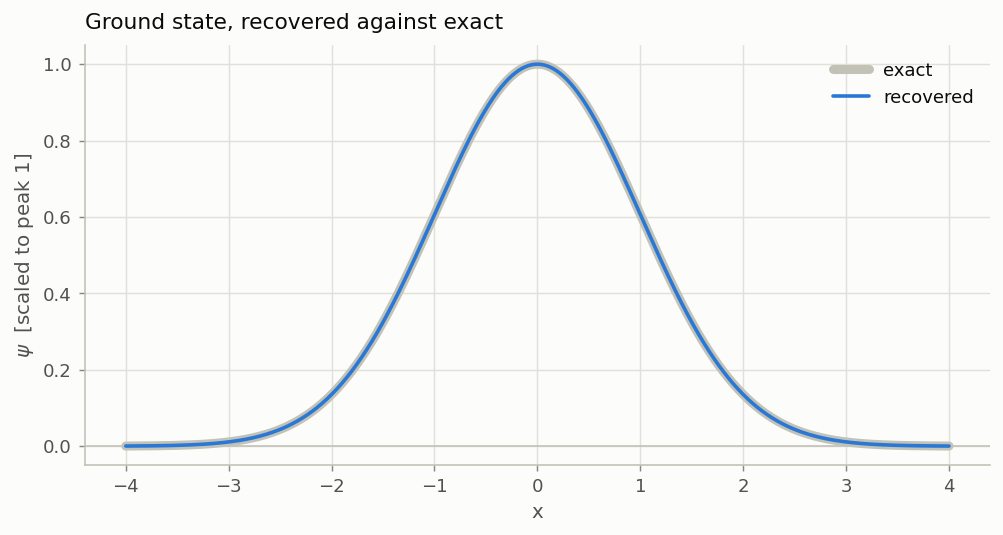

In [9]:
row0 = physical_rows(front0).iloc[0]
psi0 = wavefunction(row0.equation)
E0 = row0.E
print(row0.equation)
print(f"E = {E0:.6f}    exact {harmonic_energy(0)}      decay {row0.decay:.2e}")
s3.plot_candidate(psi0, harmonic_exact(0), title="Ground state, recovered against exact")

That is $\psi_0 = e^{-x^2/2}$ and $E_0 = \tfrac12$, from a grid of $x$ values and a potential and
nothing else.

The overall scale of the recovered $\psi$ comes back small, because the anchor is the one term in
the residual that is not invariant under $\psi \to c\psi$ and the search can cheapen it by
shrinking the amplitude. That costs us nothing, since normalisation was never determined here
anyway, and it is why the figure above compares shapes with both curves scaled to peak at one.

A useful check is to take the recovered $\psi$, differentiate it numerically with no reference to
what the search was optimising, and ask whether its local energy is actually flat.

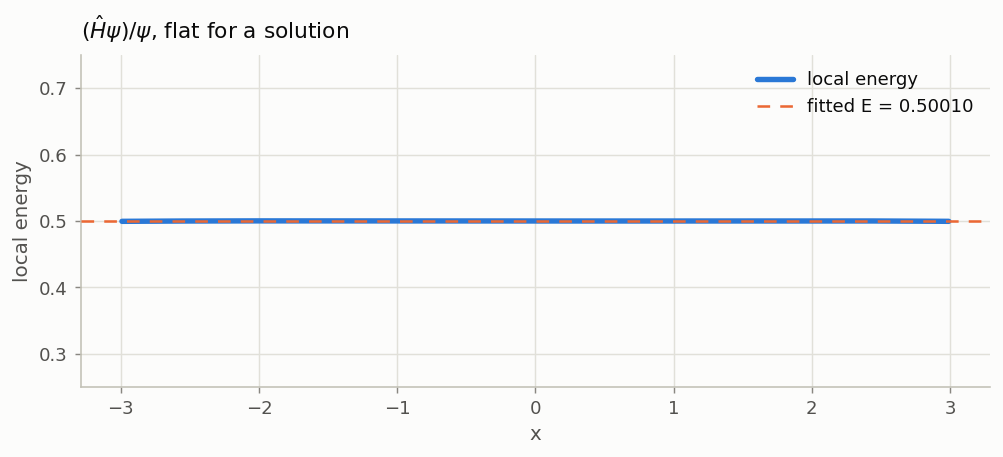

In [10]:
s3.plot_local_energy_1d(psi0, harmonic, E0)

## 7. Choosing which state you get

Here is where templates stop being a convenience and start doing the physics.

The residual is satisfied by *every* eigenstate, so nothing so far says which one we get. What
separates them is nodes: $\psi_n$ crosses zero $n$ times, and that is the only thing that
distinguishes the ground state from the rest. So we write the node structure into the template and
leave everything else free,

$$\psi(x) = N(x)\, f(x)$$

with $N$ known and $f$ nodeless. For the first excited state $N = x$, and by the product rule
$\psi'' = 2f' + x f''$, which we write out directly in the combine string. Dividing the residual by
$f$ rather than by $\psi$ keeps it finite where $\psi$ legitimately vanishes.

21s
E = 1.500226    exact 1.5


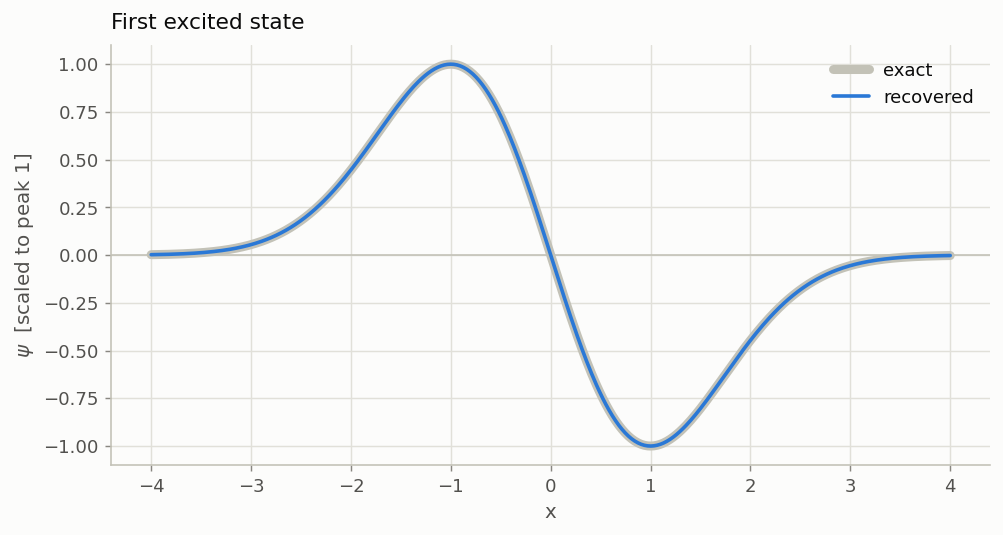

In [11]:
# psi = x f  ->  psi'' = 2 f' + x f''
N1 = ("d1 = D(f, 1); d2 = D(d1, 1); fx = f(x); "
      "(-d1(x) - 0.5f0*x*d2(x) + (V - E[1])*x*fx) / fx + w*fx*fx")

first = solve_1d(N1, {"E": 1})
front1 = classify_front_1d(first, node_factor=lambda x: x)
row1 = physical_rows(front1).iloc[0]
psi1, E1 = wavefunction(row1.equation, node_factor=lambda x: x), row1.E
print(f"E = {E1:.6f}    exact {harmonic_energy(1)}")
s3.plot_candidate(psi1, harmonic_exact(1), title="First excited state")

Same equation, same collocation points, same operators, and a different physical state comes out,
chosen entirely by the shape we asked for. That is about as direct a demonstration of a structural
prior changing the answer as this tutorial has.

Two nodes next. Now $N(x) = x^2 + c$, and we do not know where the nodes sit, so $c$ becomes a
second fitted parameter alongside $E$ and the search has to place them itself.

In [12]:
# psi = (x^2 + c) f  ->  psi'' = 2 f + 4 x f' + (x^2 + c) f''
N2 = ("d1 = D(f, 1); d2 = D(d1, 1); fx = f(x); N = x*x + c[1]; "
      "(-0.5f0*(2.0f0*fx + 4.0f0*x*d1(x) + N*d2(x)) + (V - E[1])*N*fx) / fx "
      "+ w*fx*fx")

second = solve_1d(N2, {"E": 1, "c": 1}, maxsize=16)
second.equations_[["complexity", "loss", "equation"]]

32s


,complexity,loss,equation
0,1,101.482310,f = -0.00011056629; E = [1.0401572]; c = [-11....
1,5,100.479744,f = (#1 - -0.02823965) * -0.0008788068; E = [1...
2,6,0.000092,f = exp((-0.49983972 * #1) * #1); E = [2.50300...
3,8,0.000003,f = exp(#1 * (#1 * -0.4999589)) * 0.0002887360...
4,10,0.000003,f = exp(((#1 * -0.4999589) * #1) - 31.836859) ...
5,13,0.000003,f = exp((#1 * (#1 * -0.4999589)) - exp(#1 - #1...


E = 2.500792   exact 2.5
c = -0.50050   exact -0.5, so nodes at x = +-0.7075


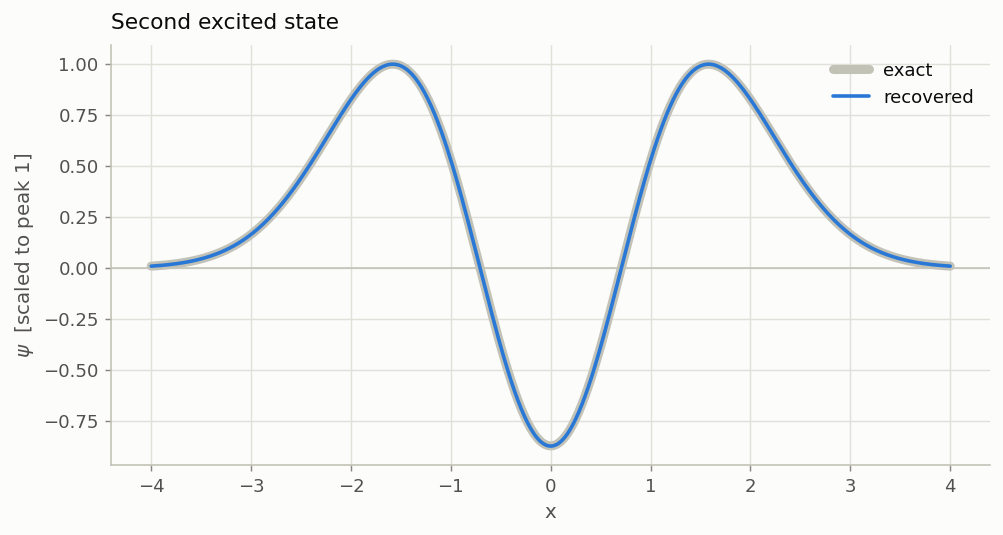

In [13]:
# The anchor sets a higher residual floor for this wider template, so an absolute
# "solved" threshold is the wrong tool here. Take the simplest row within a
# whisker of the best loss, the same rule `simplest_within` uses elsewhere,
# rather than the single lowest-loss row, which the front's own rounding can
# make an unstable choice among several rows that are equally good.
front2 = second.equations_.reset_index(drop=True)
row2 = front2[front2.loss <= front2.loss.min() * 1.5].sort_values("complexity").iloc[0]
c2, E2 = parameter(row2.equation, "c"), energy(row2.equation)
psi2 = wavefunction(row2.equation, node_factor=lambda x: x ** 2 + c2)
print(f"E = {E2:.6f}   exact {harmonic_energy(2)}")
print(f"c = {c2:.5f}   exact -0.5, so nodes at x = +-{abs(c2) ** 0.5:.4f}")
s3.plot_candidate(psi2, harmonic_exact(2), title="Second excited state")

The nodes land where Hermite says they should, and the energy comes with them.

## 8. The spectrum

Three searches, run one after another, sharing no parameters and never comparing notes. Each was
told how many times its wavefunction crosses zero and nothing else. Put the three energies side by
side.

n = 0    recovered 0.500104    exact 0.5    error 1.0e-04
n = 1    recovered 1.500226    exact 1.5    error 2.3e-04
n = 2    recovered 2.500792    exact 2.5    error 7.9e-04


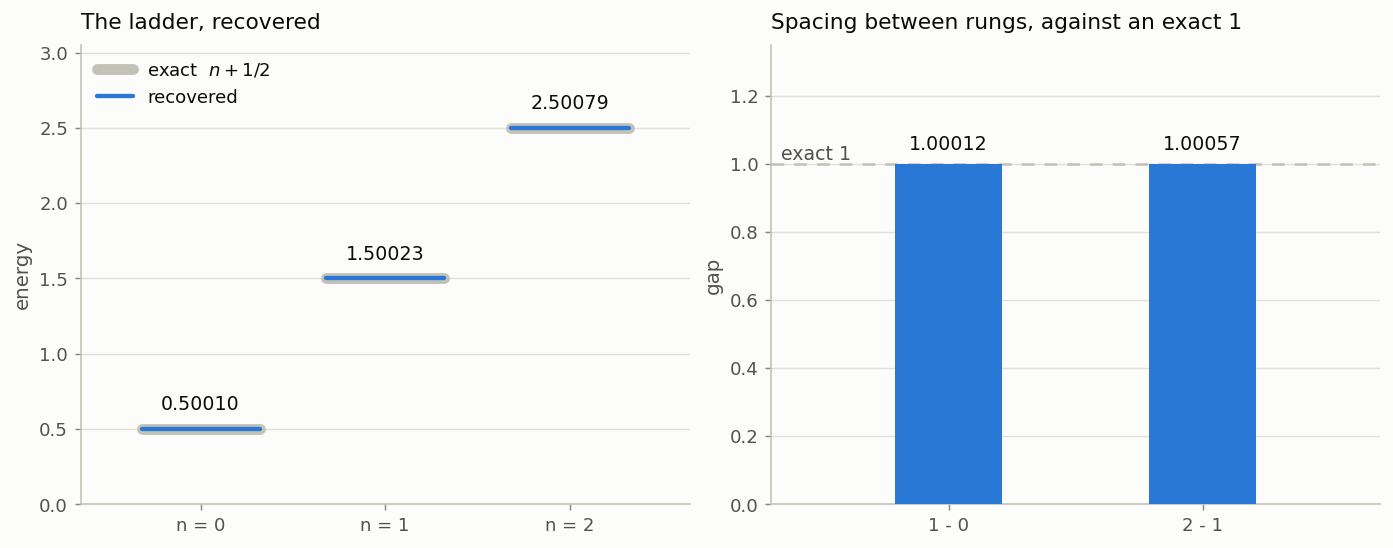

In [14]:
found = {0: E0, 1: E1, 2: E2}
for n, E in found.items():
    print(f"n = {n}    recovered {E:.6f}    exact {harmonic_energy(n):.1f}"
          f"    error {abs(E - harmonic_energy(n)):.1e}")
s3.plot_spectrum(found)

The rungs are evenly spaced, one unit apart, which is the signature of this well and the reason
the oscillator is the model for everything from a vibrating molecule to a mode of the
electromagnetic field. Nothing in the setup knew that. We supplied a parabola and a node count,
and the ladder came back on its own, in closed form, one rung at a time.

That is the mechanism, complete. Part II runs the same machinery on something we cannot solve by
staring at it.

---

# Part II. Hydrogen, and a coincidence that isn't one

Now the real atom. Same idea, one equation and a grid of points where we insist it holds,

$$-\tfrac12 \nabla^2 \psi - \frac{\psi}{r} = E\,\psi$$

in atomic units, where the potential is the pull of the proton. The interesting part is not that
it works. It is what the answers turn out to have in common, which is something nobody would
predict from the equation by looking at it, and which stopped being a coincidence only when Pauli
explained it.

## 9. The prior that turns a 3D problem into a 1D one

A search over functions of three variables would be hopeless, and we do not have to run one,
because we already know how the angles work. Every solution of a central-force problem factors
into a radial part and a spherical harmonic,

$$\psi(r, \theta, \phi) = R(r)\, Y_{\ell m}(\theta, \phi),$$

and this is the thing we are handing over. It is exactly the move from this morning, a structural
prior written into a template, and here it does something dramatic. Put that form into the
Laplacian and the angular dependence cancels out of the equation completely, leaving one ordinary
differential equation in $r$ alone,

$$-\tfrac12\left[R'' + \frac{2}{r}R' - \frac{\ell(\ell+1)}{r^2}R\right] - \frac{R}{r} = E\,R.$$

The spherical harmonic never appears again. All that survives of it is the integer $\ell$ in that
centrifugal term, so the search has to find a function of one variable and one number, which is
the situation we were in all through Part I.

We can check the cancellation is real rather than take it on faith. Below is the local energy of
an exact solution evaluated along different polar angles, which should not depend on $\theta$ at
all if the factorisation did what we claimed.

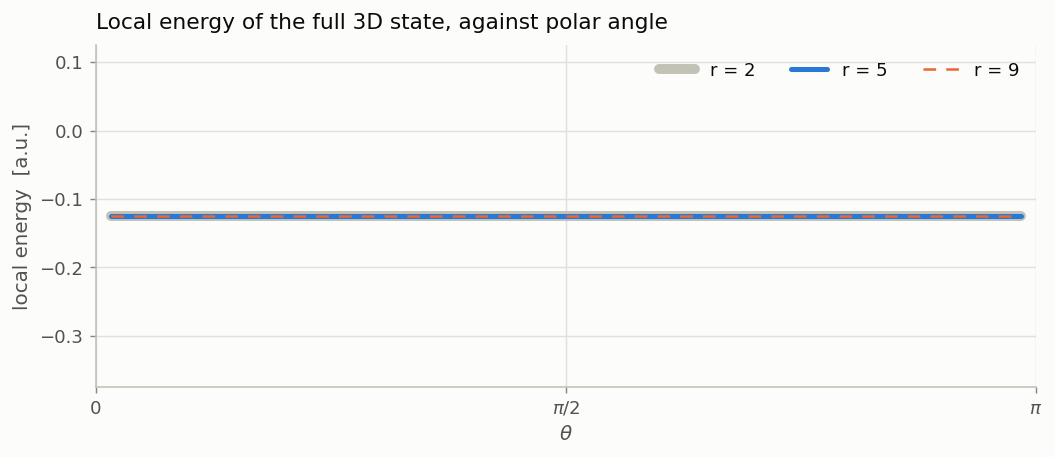

In [15]:
s3.plot_angular_check(exact_radial(2, 1), l=1)

Three radii, three flat lines, and they lie on top of each other at the same value, none of them
bending as $\theta$ sweeps from pole to pole. The angles really are gone.

## 10. The machinery, again

Almost identical to Part I. `D(R, 1)` differentiates the component, composing twice gives $R''$,
and the residual is the template's own output, minimised against a column of zeros. Dividing by
$R$ makes the trivial $R = 0$ non-finite so the search cannot take it, and makes the
differential-equation part invariant under $R \to cR$. The decay anchor `w*R*R` is doing the job it
did in section 6, and it is still the one term that is not invariant, which is the price of asking
for a normalisable solution at all.

The potential travels as an ordinary column, which will matter a great deal in section 14.

In [16]:
NODELESS = ("d1 = D(R, 1); d2 = D(d1, 1); Rr = R(r); "
            "kin = -0.5f0*(d2(r) + (2.0f0/r)*d1(r) - L*Rr/(r*r)); "
            "(kin + V*Rr)/Rr - E[1] + w*Rr*Rr")

# For a state with one radial node, write R = (r + c) f(r) and divide by f rather
# than by R, so the residual stays finite where R legitimately vanishes. E has to
# multiply the whole of R inside the numerator, not sit outside the division.
ONE_NODE = ("d1 = D(R, 1); d2 = D(d1, 1); f = R(r); N = r + c[1]; "
            "Rr = N*f; dR = f + N*d1(r); ddR = 2.0f0*d1(r) + N*d2(r); "
            "kin = -0.5f0*(ddR + (2.0f0/r)*dR - L*Rr/(r*r)); "
            "(kin + V*Rr - E[1]*Rr)/f + w*f*f")

SEARCH = dict(binary_operators=["+", "-", "*"], unary_operators=["exp"],
              elementwise_loss="(p, t) -> p^2", niterations=30, maxsize=14, **REPRO)

def solve_radial(combine, parameters, X, y, seed=0, **kw):
    spec = TemplateExpressionSpec(expressions=["R"], variable_names=COLS,
                                  parameters=parameters, combine=combine)
    t = time.time()
    m = PySRRegressor(expression_spec=spec, random_state=seed, **{**SEARCH, **kw})
    m.fit(X, y, variable_names=COLS)
    print(f"{time.time() - t:.0f}s")
    return m

## 11. The ground state

Start with $\ell = 0$, no angular momentum, and ask for the simplest thing that satisfies the
equation and decays.

In [17]:
Xh, yh = radial_grid(l=0, potential=coulomb, lo=0.4, hi=14.0)
h1s = solve_radial(NODELESS, {"E": 1}, Xh, yh)
front1s = classify_front(h1s)
row = s3.simplest_within(front1s[front1s.bound])
R_1s = radial_function(row.equation)
print(f"{row.equation}\nE = {row.E:.6f}      exact {exact_energy(1)}")

24s
R = exp(-0.57103765 - #1); E = [-0.5]
E = -0.500000      exact -0.5


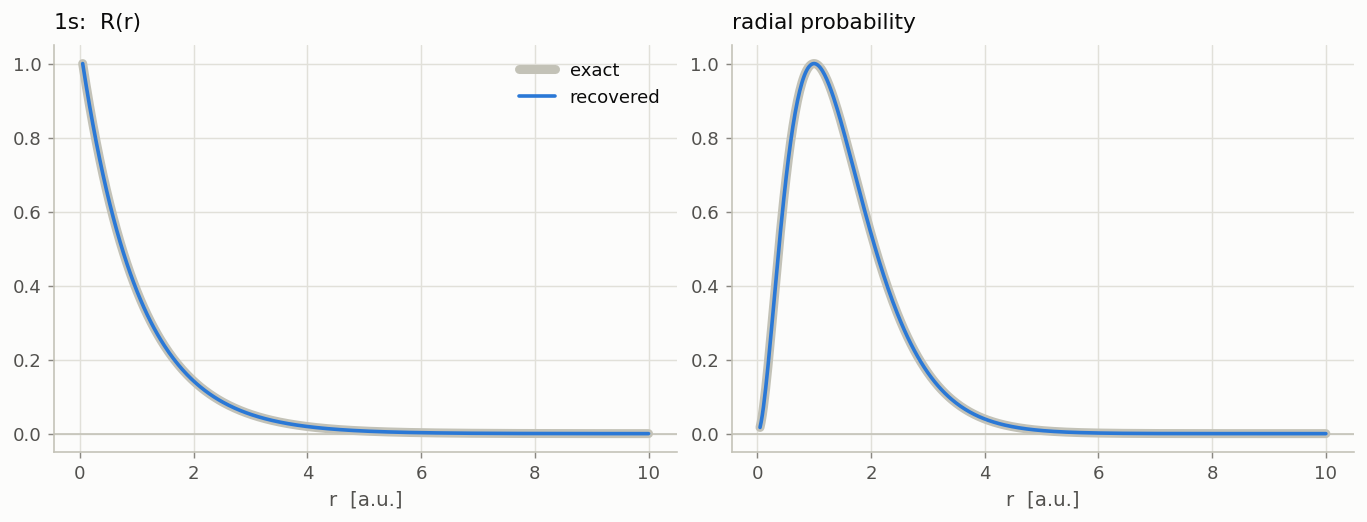

In [18]:
s3.plot_radial(R_1s, n=1, l=0, hi=10.0)

That is $R = e^{-r}$ up to the normalisation the equation never fixed, and $E = -\tfrac12$
hartree, which is $-13.6$ eV, so it costs $13.6$ eV to pull the electron off. That number came out
of a grid of radii and nothing else.

## 12. Give it angular momentum

Now $\ell = 1$. The only change is the integer in the centrifugal term, and the lowest state that
can live there is the 2p.

In [19]:
Xh, yh = radial_grid(l=1, potential=coulomb, lo=0.4, hi=24.0)
h2p = solve_radial(NODELESS, {"E": 1}, Xh, yh)
row2p = best_bound(classify_front(h2p))
R_2p = radial_function(row2p.equation)
print(f"{row2p.equation}\nE = {row2p.E:.6f}      exact {exact_energy(2)}")

19s
R = exp(-0.49999976 * #1) * #1; E = [-0.124999896]
E = -0.125000      exact -0.125


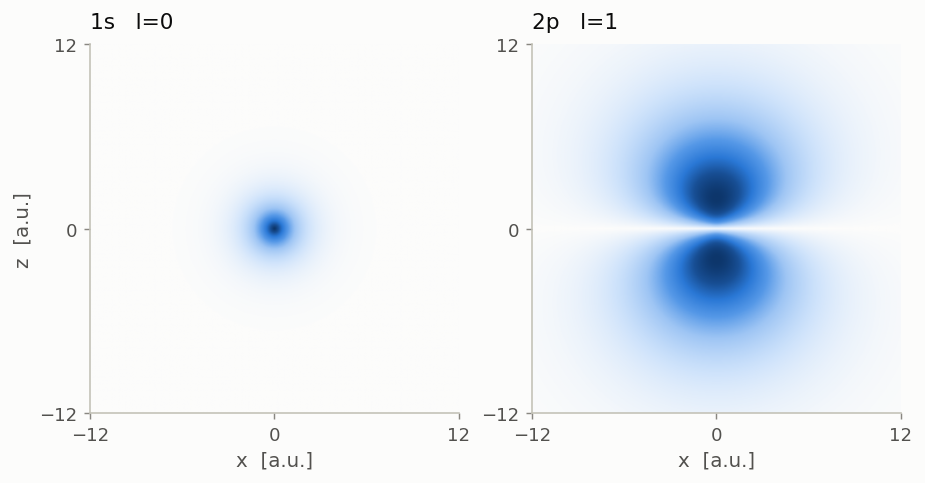

In [20]:
s3.plot_orbitals([("1s   l=0", R_1s, 0, 0), ("2p   l=1", R_2p, 1, 0)])

$R = r\,e^{-r/2}$, and the picture is the dumbbell every chemistry course draws, with its nodal
plane through the nucleus. Both panels are drawn on the same spatial axes, so the 2p being visibly
larger than the 1s is a real statement about the atom and not a choice of framing. The shading in
each panel is normalised to its own peak, since what we are reading off is shape.

## 13. Now the question worth stopping on

Next we go back to $\ell = 0$ and ask for the *next* state up, the 2s. It is a different beast from
the 2p in every way we can name. It has no angular momentum at all where the 2p has one unit. It is
spherically symmetric where the 2p is a dumbbell. Its radial part has a node, a sphere where the
electron is never found, which the 2p does not have. The two live in different angular momentum
sectors and satisfy different differential equations.

Before running the cell, it is worth committing to a guess. What energy comes back?

One bookkeeping note for reading the output. The template fits the smooth factor $f$ and calls it
`R`, so the printed `R = ...` is $f$, and the radial function is $(r + c)\,f(r)$ with the node
sitting at $r = -c$.

In [21]:
Xh, yh = radial_grid(l=0, potential=coulomb, lo=0.4, hi=24.0)
h2s = solve_radial(ONE_NODE, {"E": 1, "c": 1}, Xh, yh, maxsize=16)

# Every row on this front fits its own c, so there is no single node factor to
# hand `classify_front` the way sections 11 and 12 could; `decay` here reads on
# the smooth factor f alone, not the true R = (r+c)f. Take the simplest row that
# solves the equation, then build R for it and check the real decay explicitly.
front = classify_front(h2s, node_factor=None)
best = s3.simplest_within(front[front.solved])
c2s = parameter(best.equation, "c")
R_2s = radial_function(best.equation, node_factor=lambda r: r + c2s)
print(f"{best.equation}")
print(f"E = {energy(best.equation):.6f}      2p came back with {row2p.E:.6f}")
print(f"node at r = {-c2s:.4f}      exact 2")
print(f"decay of the true R, tail/peak = {s3.tail_ratio(R_2s):.1e}")

33s
R = exp((0.8076241 - #1) * 0.49994767); E = [-0.12498001]; c = [-2.0001915]
E = -0.124980      2p came back with -0.125000
node at r = 2.0002      exact 2
decay of the true R, tail/peak = 4.2e-12


Before comparing energies, one check that owes nothing to the search. Take the $R$ that came back,
differentiate it numerically, and evaluate $(\hat H \psi)/\psi$ point by point, exactly as we did
for the oscillator ground state. If this is really an eigenfunction the answer is a constant, and
the constant is the energy. We start at $r = 3$ to stay clear of the node, where the ratio is
legitimately undefined.

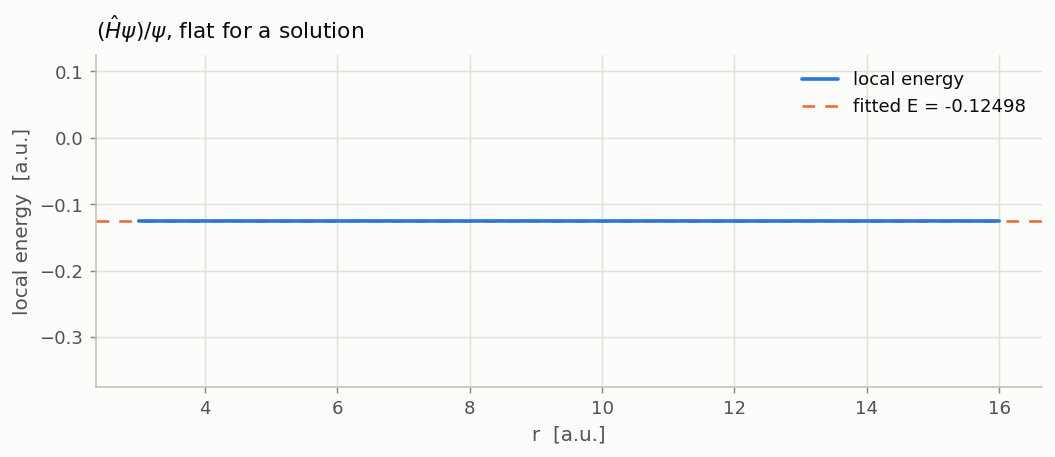

In [22]:
s3.plot_local_energy(R_2s, l=0, E=energy(best.equation), lo=3.0, hi=16.0)

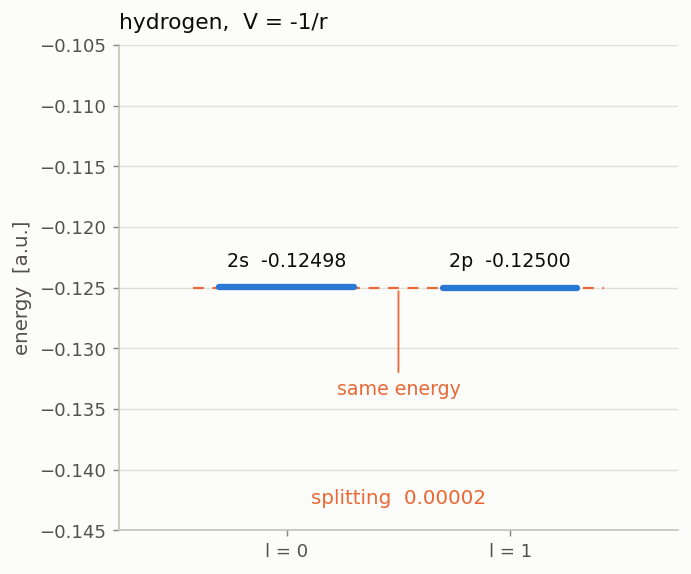

In [23]:
s3.plot_levels([("hydrogen,  V = -1/r",
                 {"2s": (0, energy(best.equation)), "2p": (1, row2p.E)})],
               ylim=(-0.145, -0.105))

The same energy. Not close, the same, to as many digits as the search resolves.

## 14. Why that should bother you

Nothing in the setup encouraged this. The two calculations shared no parameters, ran on different
differential equations, and produced functions of completely different shape. The degeneracy in $m$
is unremarkable, since space has no preferred direction and rotating a state cannot change its
energy. This is different: it is a degeneracy between different $\ell$, and rotational symmetry has
nothing to say about it. For a hundred years it was called the *accidental* degeneracy, which is a
confession rather than an explanation.

It is not accidental, and it is not a fact about quantum mechanics. It is a fact about $1/r$. The
Coulomb problem has a conserved quantity beyond energy and angular momentum, the Laplace-Runge-Lenz
vector, the same one that keeps the axis of a Kepler orbit from precessing. Its conservation
enlarges the symmetry group from rotations in three dimensions to rotations in four, and the extra
symmetry is what forces states of different $\ell$ onto the same level. Pauli used exactly this to
solve hydrogen algebraically in 1926, and his paper reached the journal ten days before
Schrödinger's first wave-mechanics paper reached its own.

The claim that it belongs to $1/r$ rather than to quantum mechanics is testable. Below is the same
template on a different `V` column, the three-dimensional version of the oscillator we spent Part I
on. The nodeless run is unchanged, and the one-node run needs a node factor of $(r^2 + c)$ instead
of $(r + c)$, because the oscillator's node sits where $r^2$ does the work. Nothing else moves.

In [24]:
# Same template as section 12, unchanged. The V column is the only difference.
Xo, yo = radial_grid(l=1, potential=oscillator, lo=0.3, hi=5.5)
o_l1 = solve_radial(NODELESS, {"E": 1}, Xo, yo)
row_l1 = best_bound(classify_front(o_l1))
print(f"l=1, no node : E = {row_l1.E:.5f}   exact {oscillator_energy(0, 1)}")

24s
l=1, no node : E = 2.50009   exact 2.5


In [25]:
Xo, yo = radial_grid(l=0, potential=oscillator, lo=0.3, hi=5.5)
NODE_R2 = ("d1 = D(R, 1); d2 = D(d1, 1); f = R(r); N = r*r + c[1]; "
           "Rr = N*f; dR = 2.0f0*r*f + N*d1(r); "
           "ddR = 2.0f0*f + 4.0f0*r*d1(r) + N*d2(r); "
           "kin = -0.5f0*(ddR + (2.0f0/r)*dR - L*Rr/(r*r)); "
           "(kin + V*Rr - E[1]*Rr)/f + w*f*f")

o_l0 = solve_radial(NODE_R2, {"E": 1, "c": 1}, Xo, yo, maxsize=16)
best_o = s3.simplest_within(classify_front(o_l0))
print(f"l=0, one node: E = {energy(best_o.equation):.5f}   exact {oscillator_energy(1, 0)}")

46s
l=0, one node: E = 3.50483   exact 3.5


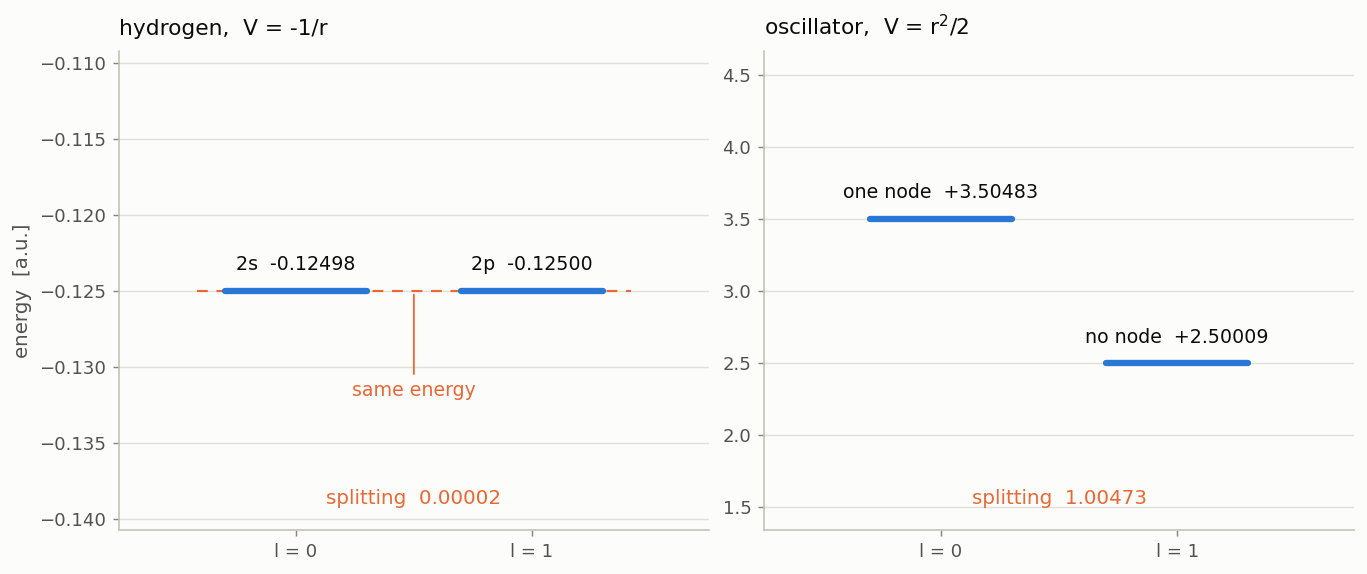

In [26]:
s3.plot_levels([
    ("hydrogen,  V = -1/r",
     {"2s": (0, energy(best.equation)), "2p": (1, row2p.E)}),
    ("oscillator,  V = r$^2$/2",
     {"one node": (0, energy(best_o.equation)), "no node": (1, row_l1.E)}),
], ylim=None)

Same pair of quantum numbers, same machinery, and in the oscillator they sit a full unit apart. The
hydrogen degeneracy was never a generic feature of central potentials, and a room that had only
ever seen hydrogen would have had no way to know that.

One caveat before we move on, because a sharp student in the room will raise it. The oscillator is
not an innocent bystander. It carries an extra symmetry of its own, an SU(3) where hydrogen has an
SO(4), and that is why its energy depends on $2n_r + \ell$ while hydrogen's depends on
$n_r + \ell$. Ask the oscillator for $\ell = 2$ with no node and $3.5$ comes back again, degenerate
with the one-node $\ell = 0$ state we just found. What the two panels compare is therefore the
*pattern* of the degeneracy, and that pattern is a fingerprint of which potential you are standing
in. Bertrand's theorem says $-1/r$ and $r^2$ are the only two that have such a pattern at all, and
they are the same two whose classical orbits close.

## 15. What this does and does not do

The honest limits are worth saying out loud, because six states in a few minutes can leave the
wrong impression.

Nothing here came back exact. The oscillator energies in Part I are good to three or four digits
and no further, with the error growing as we climb the ladder, hydrogen's 2s decay constant is
$0.49995$ with its node at $2.0002$, and the residual is small rather than zero. Everything worked because the answers are short expressions in the
operators we supplied. Gaussians and exponentials times polynomials are one `exp` away, so both of
these potentials are close to the friendliest possible targets, and the moment a problem needs a
function outside that set the search returns a plausible approximation rather than the truth, which
is harder to notice than an outright failure. We saw a version of this while building the session:
adding a $\lambda/r^2$ screening term to break the degeneracy the other way gives solutions that go
like $r^{1.0652}$, and no combination of `+`, `-`, `*` and `exp` can produce a non-integer power, so
that route was abandoned in favour of the oscillator comparison you just ran.

The node structure is ours, not the search's. Telling it $\psi = (x^2 + c)f$ is telling it there
are two nodes, and it only found where. Nothing stops $f$ from carrying a node of its own either,
so a template that asks for the wrong number can hand back a state you did not order:
$\psi = x(x^2 - \tfrac32)e^{-x^2/2}$ at $E = \tfrac72$ satisfies everything in section 7 just as
well. It did not come up on the seeds we ran, so the node count is a hint rather than a constraint,
and checking which state you actually got is the habit worth taking away.

And the residual is only ever checked at the points we chose. Between them and beyond them nothing
is enforced, which is exactly what section 5 looked like when it bit, and it is why the decay
anchor is in every combine string after it.

## 16. Over to you

The one-dimensional half first, where the searches are quick.

**Take the anchor away.** Rerun section 6 with `LOCAL` instead of `ANCHORED` across a dozen seeds
and count how often $E = -\tfrac12$ comes back. That frequency is the honest reason the anchor
exists.

**Third and fourth rungs.** $N(x) = x^3 + bx$ gives three nodes and should return $E = \tfrac72$.
How far up the ladder can you climb before the search stops finding it, and what runs out first,
the maxsize or the patience?

**A different well.** `poschl_teller` is in the module, $V = -\mathrm{sech}^2 x$, whose only bound
state is $\psi = \mathrm{sech}\,x$ at $E = -\tfrac12$. You will need `/` among the binary operators
for `sech` to be reachable at all, and a longer search, around `niterations=60` and `maxsize=20`.
Try the bare residual first and watch what turns up instead.

**Move the walls.** Change `lo` and `hi` in `collocation`. How far in can you bring the box before
the ground state stops being recoverable, and does the anchor weight need to move with it?

Then the atom.

**Climb further up the ladder.** The 3d state is $\ell = 2$ and nodeless, so `NODELESS` handles it
unchanged, and $E$ should be $-1/18$. Then 3p, which needs one node at $\ell = 1$.

**Find the whole $n = 3$ shell** and put it on a level diagram with `s3.plot_levels`. Three
different $\ell$, one energy.

**Change the nuclear charge.** `potential=lambda r: -Z/r` for $Z = 2$ is helium's ion, and the
energies should scale as $Z^2$ while the orbitals shrink by $1/Z$. Both are visible in one run.

**Break the degeneracy honestly.** A screened $-e^{-\mu r}/r$ gives a problem with no closed-form
answer, so the search cannot land on the truth. Watch what it returns instead, and how you would
know.

**Give it a potential with no formula.** Nothing in any of this used $V$ symbolically; it was
always just a column of numbers. Try a $V$ you only have on a grid, from a table or another
calculation, and the method does not change at all.

### Reference

The local energy and the reason it is the right object to make constant are standard variational
Monte Carlo material; Foulkes, Mitas, Needs and Rajagopal, *Quantum Monte Carlo simulations of
solids*, Rev. Mod. Phys. 73, 33 (2001) is the usual starting point. Pauli's algebraic solution of
hydrogen is *Über das Wasserstoffspektrum vom Standpunkt der neuen Quantenmechanik*, Z. Phys. 36,
336 (1926), and for the SO(4) symmetry and the Runge-Lenz vector in modern language, Chapter 4 of
Biedenharn and Louck or the treatment in Sakurai's *Modern Quantum Mechanics* both work. The
differential operator inside template expressions is documented with the rest of PySR's template
machinery at <https://ai.damtp.cam.ac.uk/pysr/>.